<a href="https://colab.research.google.com/github/redgrave17/finalproject/blob/main/smartline_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Smartline gas versus heat-pump household comparison

Smartline sensor files, for the matched pair **UPRN 111 (gas)** and **UPRN 15 (ASHP)**.

Figure map (report numbering):

| Notebook | Report | Output file |
|---|---|---|
| Section 5 | Fig. 1 | `fig1_cohort.png` |
| Section 7 | Fig. 2 | `fig2_monthly_series.png` |
| Section 7 | Fig. 3 | `fig3_contrasts.png` |
| Section 8 | Fig. 4 | `fig4_physics.png` |
| Section 9 | Fig. 5 | `fig5_costs.png` |
| Section 10 | Fig. 6 | `fig6_harmonic.png` |
| Section 5 | Table 1 | `table1_candidate_pairings.csv` |
| Section 6 | Table 2 | `table2_gas_subset_scenario.csv` |

Section 11 prints every number the report quotes, in one place.

**Data access.** Smartline data

## 1. Imports

In [14]:
from __future__ import annotations

import re
import warnings
from dataclasses import dataclass
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)

## 2. Drive, paths and constants

In [15]:
from google.colab import drive
drive.mount('/content/drive')

ROOT = Path(r'/content/drive/MyDrive/01_Smartline')
OUT  = Path(r'/content/drive/MyDrive/Colab')
FIG  = OUT / "figures"
TAB  = OUT / "tables"

SURVEY          = ROOT / "SurveyAndUprns" / "uprns.csv"
ELECTRICITY_DIR = ROOT / "SensorData" / "Electricity"
GAS_DIR         = ROOT / "SensorData" / "Gas"

# Statutory conversion: CV 39.5 MJ/m3 x 1.02264 volume correction / 3.6.
# The source spreadsheet used a flat 11.0, a ~2% understatement.
GAS_M3_TO_KWH = round(39.5 * 1.02264 / 3.6, 3)      # 11.221
BOILER_EFF    = 0.85                                 # in-situ boiler efficiency (SAP)
FIELD_SPF     = 2.9                                  # field seasonal COP (RHPP trial)
SUMMER, WINTER = (6, 7, 8), (12, 1, 2)               # JJA and DJF

# Ofgem price cap, 1 Jan - 31 Mar 2024 (historical scenario, not a current tariff)
P_ELEC, P_GAS   = 0.2862, 0.0742                     # GBP/kWh
SC_ELEC, SC_GAS = 0.5335 * 365, 0.2960 * 365         # annualised standing charges

# Carbon factors, DESNZ 2023 (kgCO2e/kWh)
CO2_GAS, CO2_ELEC = 0.183, 0.207

print(f"gas conversion {GAS_M3_TO_KWH} kWh/m3 | boiler {BOILER_EFF} | SPF {FIELD_SPF}")
print(f"break-even electricity:gas price ratio = SPF/eff = {FIELD_SPF/BOILER_EFF:.2f}")
print(f"cap ratio = {P_ELEC/P_GAS:.2f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
gas conversion 11.221 kWh/m3 | boiler 0.85 | SPF 2.9
break-even electricity:gas price ratio = SPF/eff = 3.41
cap ratio = 3.86


## 3. Helpers

In [16]:
@dataclass
class EnergyResult:
    household_features: pd.DataFrame
    daily: pd.DataFrame
    file_audit: pd.DataFrame


def ensure_dirs() -> None:
    for d in (OUT, FIG, TAB):
        d.mkdir(parents=True, exist_ok=True)


def parse_uprn(path: Path) -> int | None:
    match = re.search(r"ts_(\d+)_sid", path.name)
    return int(match.group(1)) if match else None


def first_matching_column(columns: list[str], needle: str) -> str:
    matches = [c for c in columns if needle.lower() in c.lower()]
    if not matches:
        raise ValueError(f"No column containing {needle!r}; columns={columns}")
    return matches[0]


def robust_upper_bound(series: pd.Series, absolute_cap: float | None = None) -> float:
    clean = series.dropna()
    if clean.empty:
        return np.nan
    q1, q3 = clean.quantile([0.25, 0.75])
    iqr = q3 - q1
    upper = q3 + 3 * iqr if iqr > 0 else clean.quantile(0.99)
    if absolute_cap is not None:
        upper = min(float(upper), absolute_cap)
    return float(max(upper, clean.quantile(0.95)))


def show(fig_path):
    from IPython.display import Image, display
    display(Image(filename=str(fig_path)))


ensure_dirs()

# Report palette: gas home / ASHP home / emphasis, plus chrome.
C_GAS, C_ASHP, C_EMPH, C_ALT, TEXT_2 = "#2a78d6", "#1baf7a", "#e34948", "#eb6834", "#52514e"
plt.rcParams.update({"font.size": 10.5, "axes.titlesize": 11.5, "axes.labelsize": 10.5,
                     "legend.fontsize": 9, "figure.facecolor": "white",
                     "axes.facecolor": "white", "axes.grid": True, "grid.alpha": 0.25})

## 4. Reading and cleaning meter files

`read_energy_file` is shared by both halves of the notebook. `process_energy_folder`
takes an optional UPRN filter so the gas-subset scenario reads only the 16 gas homes
and their matching electricity files, rather than all 203 electricity files.

In [17]:
def read_energy_file(path: Path) -> pd.DataFrame:
    columns = pd.read_csv(path, nrows=0).columns.tolist()
    value_col = first_matching_column(columns, "diffValue")
    df = pd.read_csv(path, usecols=["datetime", value_col]).rename(columns={value_col: "value"})
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    return df.dropna(subset=["datetime"]).sort_values("datetime")


def process_energy_folder(folder: Path, label: str, daily_cap: float | None,
                          only_uprns: set[int] | None = None) -> EnergyResult:
    feature_rows, daily_rows, audit_rows = [], [], []
    files = sorted(folder.glob("ts_*.csv"))
    if only_uprns is not None:
        files = [p for p in files if parse_uprn(p) in only_uprns]

    for i, path in enumerate(files, 1):
        if i % 25 == 0 or i in (1, len(files)):
            print(f"[{label}] {i}/{len(files)}: {path.name}", flush=True)
        uprn = parse_uprn(path)
        if uprn is None:
            continue
        try:
            raw = read_energy_file(path)
        except Exception as exc:
            audit_rows.append({"UPRN": uprn, "file": path.name, "status": f"read_error: {exc}"})
            continue

        hourly = raw.set_index("datetime")["value"].resample("h").sum(min_count=1) \
                    .rename("hourly_value").to_frame()
        hourly["negative_hour"] = hourly["hourly_value"] < 0        # sensor faults, not real use
        hourly.loc[hourly["negative_hour"], "hourly_value"] = np.nan
        hourly["date"] = hourly.index.date

        daily = (hourly.groupby("date")
                 .agg(daily_value=("hourly_value", "sum"),
                      active_hours=("hourly_value", "count"),
                      negative_hours=("negative_hour", "sum"))
                 .reset_index())
        daily["UPRN"] = uprn
        daily["date"] = pd.to_datetime(daily["date"])
        daily["month"] = daily["date"].dt.month

        upper = robust_upper_bound(daily.loc[daily["active_hours"] >= 12, "daily_value"], daily_cap)
        daily["valid_day"] = ((daily["active_hours"] >= 12)
                              & (daily["daily_value"] > 0)
                              & (daily["daily_value"] <= upper))
        valid = daily[daily["valid_day"]]
        daily_rows.append(daily)

        if len(valid) >= 30:
            feature_rows.append({
                "UPRN": uprn,
                f"{label}_valid_days": len(valid),
                f"{label}_mean_daily": valid["daily_value"].mean(),
                f"{label}_median_daily": valid["daily_value"].median(),
                f"{label}_winter_mean_daily": valid.loc[valid["month"].isin(WINTER), "daily_value"].mean(),
                f"{label}_summer_mean_daily": valid.loc[valid["month"].isin(SUMMER), "daily_value"].mean(),
            })

        audit_rows.append({"UPRN": uprn, "file": path.name, "status": "ok",
                           "raw_rows": len(raw),
                           "first_datetime": raw["datetime"].min(),
                           "last_datetime": raw["datetime"].max(),
                           "daily_upper_bound": upper,
                           "valid_days": len(valid),
                           "removed_negative_hours": int(hourly["negative_hour"].sum())})

    return EnergyResult(pd.DataFrame(feature_rows),
                        pd.concat(daily_rows, ignore_index=True) if daily_rows else pd.DataFrame(),
                        pd.DataFrame(audit_rows))

## 5. Cohort audit plus report Figure 1 and Table 1

The audit runs at two scales. The **28-home extract** is the set the previous attempt worked from. Gas need to add one more since UPRN 616's Heating field is blank in uprns.csv

SAP is excluded from the matching keys because it is missing for most ASHP homes.

277 survey homes
extract: 16 gas, 12 ASHP
  no heating type recorded in the survey for UPRN 616, assigned from the extract's own split


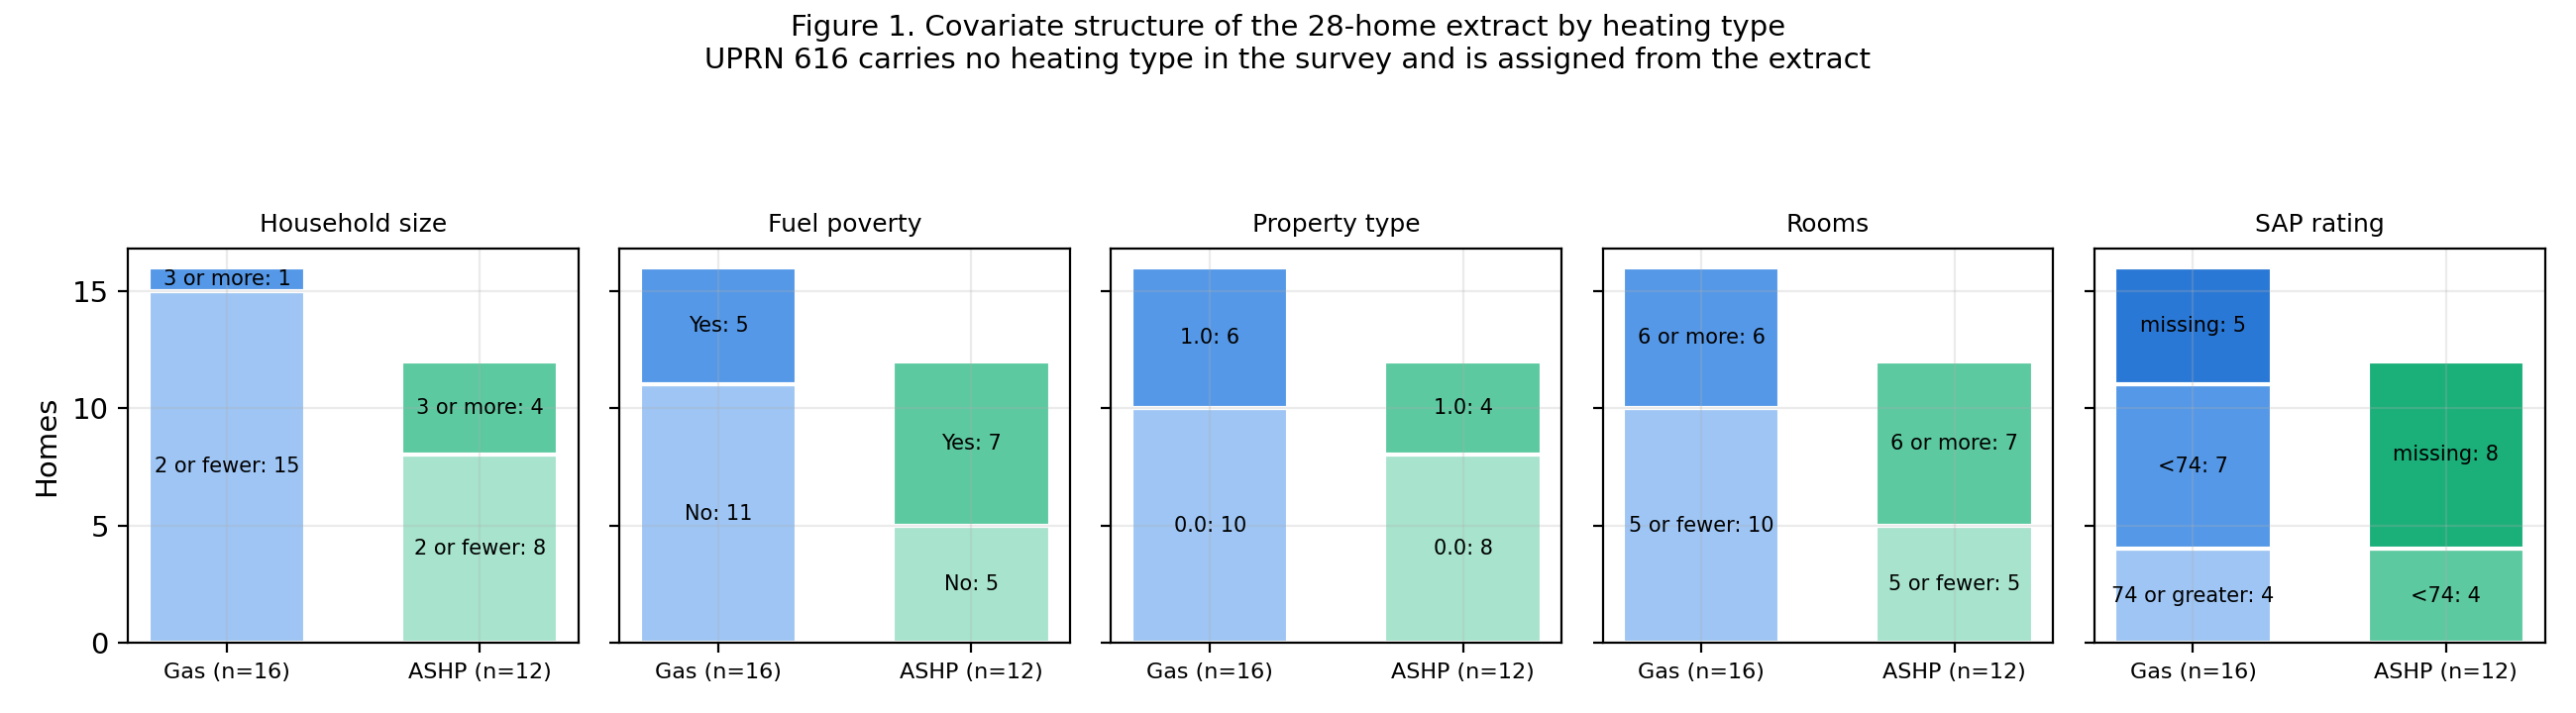

In [18]:
survey = pd.read_csv(SURVEY)
survey["UPRN"] = survey["UPRN"].astype(int)
print(f"{len(survey)} survey homes")

# Survey-wide classification, taken from the recorded heating label.
label = survey["Heating"].astype(str)
survey["label_group"] = np.where(label.str.contains("Heat Pump", case=False, na=False), "ASHP",
                        np.where(label.str.contains("Gas", case=False, na=False), "Gas", "Other"))
cohort = survey[survey["label_group"].isin(["Gas", "ASHP"])].copy()
cohort["group"] = cohort["label_group"]

# The 28 homes the previous attempt extracted (16 gas, 12 ASHP). Group membership
# here comes from the extract itself rather than from the survey's heating label,
# because the survey leaves that label blank for some of these homes.
EXTRACT_GAS  = [108, 109, 110, 111, 112, 201, 308, 616, 718, 722, 723, 806, 1458, 1741, 1783, 1785]
EXTRACT_ASHP = [1, 4, 7, 11, 14, 15, 17, 101, 103, 105, 689, 1213]

extract = survey[survey["UPRN"].isin(EXTRACT_GAS + EXTRACT_ASHP)].copy()
extract["group"] = np.where(extract["UPRN"].isin(EXTRACT_GAS), "Gas", "ASHP")

# Record which extract homes the survey does not label, so the figure's counts
# reconcile with the group's own 16/12 table.
unlabelled = sorted(extract.loc[extract["label_group"] == "Other", "UPRN"].tolist())
n_gas, n_ashp = (extract["group"] == "Gas").sum(), (extract["group"] == "ASHP").sum()
print(f"extract: {n_gas} gas, {n_ashp} ASHP")
if unlabelled:
    print(f"  no heating type recorded in the survey for UPRN "
          f"{', '.join(str(u) for u in unlabelled)}, assigned from the extract's own split")

covs = [("HouseholdSize", "Household size"), ("FuelPovertyIndicated", "Fuel poverty"),
        ("propType0F", "Property type"), ("NumberOfRooms", "Rooms"), ("SAP_Score", "SAP rating")]

fig, axes = plt.subplots(1, len(covs), figsize=(13, 3.6), sharey=True)
shades = {"Gas":  ["#9ec5f4", "#5598e7", "#2a78d6", "#184f95"],
          "ASHP": ["#a7e3cd", "#5cc9a0", "#1baf7a", "#0e7a54"]}
for ax, (col, label_txt) in zip(axes, covs):
    tab = (extract.assign(v=extract[col].fillna("missing").astype(str))
           .groupby(["group", "v"]).size().unstack("v").reindex(["Gas", "ASHP"]).fillna(0))
    bottoms = [0, 0]
    for j, cat in enumerate(sorted(tab.columns)):
        for i, g in enumerate(("Gas", "ASHP")):
            v = tab.loc[g, cat]
            ax.bar(i, v, bottom=bottoms[i], width=0.62,
                   color=shades[g][j % 4], edgecolor="white", linewidth=1.5)
            if v > 0:
                ax.annotate(f"{cat}: {int(v)}", (i, bottoms[i] + v / 2),
                            ha="center", va="center", fontsize=7.5)
            bottoms[i] += v
    ax.set_xticks([0, 1])
    ax.set_xticklabels([f"Gas (n={int(tab.loc['Gas'].sum())})",
                        f"ASHP (n={int(tab.loc['ASHP'].sum())})"], fontsize=8)
    ax.set_title(label_txt, fontsize=9)
axes[0].set_ylabel("Homes")

title = "Figure 1. Covariate structure of the 28-home extract by heating type"
if unlabelled:
    verb = "carries" if len(unlabelled) == 1 else "carry"
    title += (f"\nUPRN {', '.join(str(u) for u in unlabelled)} {verb} no heating type "
              f"in the survey and {'is' if len(unlabelled) == 1 else 'are'} assigned from the extract")
fig.suptitle(title, fontsize=10.5)
fig.tight_layout(rect=(0, 0, 1, 0.88 if unlabelled else 0.92))
fig.savefig(FIG / "fig1_cohort.png", dpi=200)
plt.close(fig)
show(FIG / "fig1_cohort.png")

In [19]:
KEYS = ["HouseholdSize", "FuelPovertyIndicated", "propType0F", "NumberOfRooms"]


def candidate_pairings(frame: pd.DataFrame, require_sensors: bool = True) -> pd.DataFrame:
    g = frame[frame["group"] == "Gas"].copy()
    a = frame[frame["group"] == "ASHP"].copy()
    if require_sensors:                       # a pairing is only usable if both meters exist
        g = g[g["SID_Gas"].notna() & g["SID_Electricity"].notna()]
        a = a[a["SID_Electricity"].notna()]
    return g.merge(a, on=KEYS, suffixes=("_gas", "_ashp"))


pairs_extract = candidate_pairings(extract)
both_fp = pairs_extract[pairs_extract["FuelPovertyIndicated"].eq("Yes")]
present = ((pairs_extract["UPRN_gas"] == 111) & (pairs_extract["UPRN_ashp"] == 15)).any()

print(f"28-home extract ({n_gas} gas x {n_ashp} ASHP): "
      f"{len(pairs_extract)} candidate pairings on the four usable keys")
print(f"  of which both homes fuel-poor: {len(both_fp)}")
print(f"  UPRN 111-15 present: {present}")
print(f"  gas homes lacking a gas or electricity sensor: "
      f"{int((extract['group'].eq('Gas') & (extract['SID_Gas'].isna() | extract['SID_Electricity'].isna())).sum())}")
print(f"  ASHP homes with no electricity sensor: "
      f"{int((extract['group'].eq('ASHP') & extract['SID_Electricity'].isna()).sum())}")

pairs_full = candidate_pairings(cohort)
print(f"full survey ({(cohort['group']=='Gas').sum()} gas-labelled vs "
      f"{(cohort['group']=='ASHP').sum()} ASHP): {len(pairs_full)} pairings  [context only]")

table1 = pairs_extract[["UPRN_gas", "UPRN_ashp"] + KEYS].sort_values(["UPRN_gas", "UPRN_ashp"])
table1.to_csv(TAB / "table1_candidate_pairings.csv", index=False)
table1

28-home extract (16 gas x 12 ASHP): 11 candidate pairings on the four usable keys
  of which both homes fuel-poor: 4
  UPRN 111-15 present: True
  gas homes lacking a gas or electricity sensor: 4
  ASHP homes with no electricity sensor: 1
full survey (241 gas-labelled vs 12 ASHP): 11 pairings  [context only]


,UPRN_gas,UPRN_ashp,HouseholdSize,FuelPovertyIndicated,propType0F,NumberOfRooms
0,109,11,2 or fewer,No,0.0,5 or fewer
1,111,15,2 or fewer,Yes,0.0,6 or more
2,112,7,2 or fewer,No,0.0,6 or more
3,112,14,2 or fewer,No,0.0,6 or more
4,308,17,2 or fewer,Yes,0.0,5 or fewer
5,308,1213,2 or fewer,Yes,0.0,5 or fewer
6,723,689,2 or fewer,Yes,1.0,5 or fewer
7,1458,11,2 or fewer,No,0.0,5 or fewer
8,1783,11,2 or fewer,No,0.0,5 or fewer
9,1785,7,2 or fewer,No,0.0,6 or more


## 6. Gas-subset heat-pump scenario plus report Table 2

In [20]:
gas_uprns = {parse_uprn(p) for p in sorted(GAS_DIR.glob("ts_*.csv"))} - {None}
print(f"{len(gas_uprns)} homes in the gas subset")

gas_res  = process_energy_folder(GAS_DIR, "gas", daily_cap=20)
elec_res = process_energy_folder(ELECTRICITY_DIR, "electricity", daily_cap=80,
                                 only_uprns=gas_uprns)          # only the gas homes' meters

scenario = gas_res.household_features.merge(
    elec_res.household_features[["UPRN", "electricity_mean_daily", "electricity_valid_days"]],
    on="UPRN", how="left")
scenario["gas_mean_daily_kwh"] = scenario["gas_mean_daily"] * GAS_M3_TO_KWH
scenario["hp_added_daily_kwh"] = scenario["gas_mean_daily_kwh"] * BOILER_EFF / FIELD_SPF
scenario["new_electricity_daily_kwh"] = (scenario["electricity_mean_daily"]
                                         + scenario["hp_added_daily_kwh"])
scenario["electricity_multiplier"] = (scenario["new_electricity_daily_kwh"]
                                      / scenario["electricity_mean_daily"])
scenario["anonymous_gas_home"] = [f"G{i:02d}" for i in range(1, len(scenario) + 1)]

mult = scenario["electricity_multiplier"].dropna()
print(f"\nmultipliers available for {len(mult)} of {len(scenario)} gas homes "
      f"({len(scenario) - len(mult)} lack usable electricity data)")
print(f"range {mult.min():.2f} to {mult.max():.2f}, median {mult.median():.2f}")

table2 = scenario[["anonymous_gas_home", "gas_mean_daily_kwh", "electricity_mean_daily",
                   "hp_added_daily_kwh", "electricity_multiplier"]].round(2)
table2.to_csv(TAB / "table2_gas_subset_scenario.csv", index=False)
table2

16 homes in the gas subset
[gas] 1/16: ts_0108_sid63212431.csv
[gas] 16/16: ts_1785_sid63212811.csv
[electricity] 1/12: ts_0109_sid63214361.csv
[electricity] 12/12: ts_1785_sid63241881.csv

multipliers available for 12 of 16 gas homes (4 lack usable electricity data)
range 1.15 to 2.67, median 1.78


,anonymous_gas_home,gas_mean_daily_kwh,electricity_mean_daily,hp_added_daily_kwh,electricity_multiplier
0,G01,19.79,NaN,5.80,NaN
1,G02,16.40,5.35,4.81,1.90
2,G03,5.21,5.03,1.53,1.30
3,G04,22.44,7.21,6.58,1.91
4,G05,15.70,5.58,4.60,1.82
5,G06,22.76,4.00,6.67,2.67
6,G07,22.60,6.09,6.62,2.09
7,G08,20.49,8.10,6.01,1.74
8,G09,11.51,5.72,3.37,1.59
9,G10,12.63,NaN,3.70,NaN


## 7. Rebuild the matched pair, and report Figures 2 and 3

The pair's monthly table is rebuilt from the raw minute-level streams, then restricted
to the report's core window, the two complete June–May seasonal years. The partial
May 2018 gas month and the incomplete third year are dropped so each calendar month
appears exactly twice.

In [21]:
def monthly_from_raw(folder: Path, uprn: int) -> pd.Series:
    files = sorted(folder.glob(f"ts_{uprn:04d}_sid*.csv"))
    if not files:
        raise FileNotFoundError(f"no sensor file for UPRN {uprn} in {folder}")
    s = read_energy_file(files[0]).set_index("datetime")["value"]
    s = s[s >= 0]                                    # drop negative increments (sensor faults)
    return s.resample("MS").sum()


pair = pd.DataFrame({
    "gas_m3":        monthly_from_raw(GAS_DIR, 111),
    "gash_elec_kwh": monthly_from_raw(ELECTRICITY_DIR, 111),
    "ashp_elec_kwh": monthly_from_raw(ELECTRICITY_DIR, 15),
}).dropna()
pair["gas_kwh"] = pair["gas_m3"] * GAS_M3_TO_KWH
pair["gash_total_kwh"] = pair["gas_kwh"] + pair["gash_elec_kwh"]

pair = pair.loc["2018-06-01":"2020-05-01"].copy()
pair["sy"] = np.where(pair.index.month >= 6, pair.index.year, pair.index.year - 1)
assert len(pair) == 24 and sorted(pair["sy"].unique()) == [2018, 2019]

print(f"{len(pair)} complete months, {pair.index.min():%b %Y} to {pair.index.max():%b %Y}")
pair.round(1)

24 complete months, Jun 2018 to May 2020


,gas_m3,gash_elec_kwh,ashp_elec_kwh,gas_kwh,gash_total_kwh,sy
datetime,,,,,,
2018-06-01,24.4,244.7,222.1,273.5,518.2,2018
2018-07-01,7.9,227.4,215.7,88.9,316.3,2018
2018-08-01,15.8,231.4,269.3,177.5,408.9,2018
2018-09-01,30.4,215.8,235.8,341.2,557.0,2018
2018-10-01,73.4,261.9,287.6,823.7,1085.6,2018
2018-11-01,121.1,258.0,234.8,1359.1,1617.1,2018
2018-12-01,121.8,294.5,235.5,1366.7,1661.2,2018
2019-01-01,138.8,280.6,252.7,1557.6,1838.2,2018
2019-02-01,118.4,239.3,218.4,1328.2,1567.5,2018


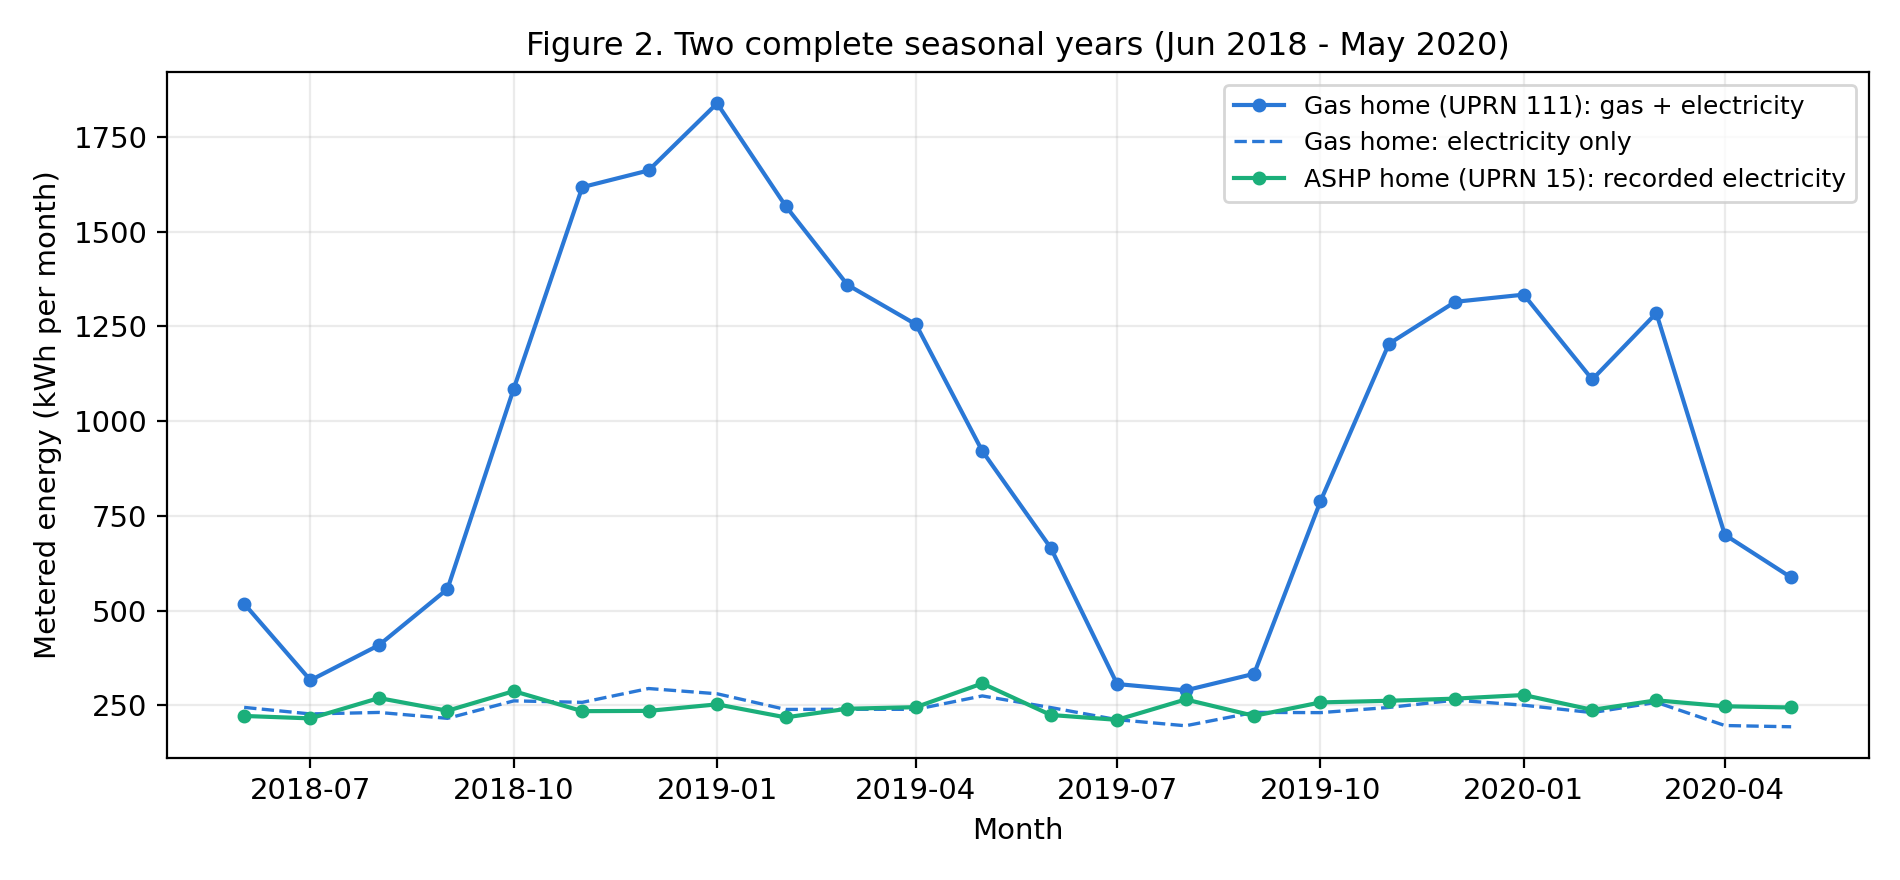

winter-minus-summer contrast, kWh/month (winter:summer ratio):
  gash_total_kwh_2018:   1274.5  (4.07)
  gash_total_kwh_2019:    832.3  (2.98)
  gash_elec_kwh_2018:     37.0  (1.16)
  gash_elec_kwh_2019:     30.8  (1.14)
  ashp_elec_kwh_2018:     -0.2  (1.00)
  ashp_elec_kwh_2019:     27.1  (1.12)


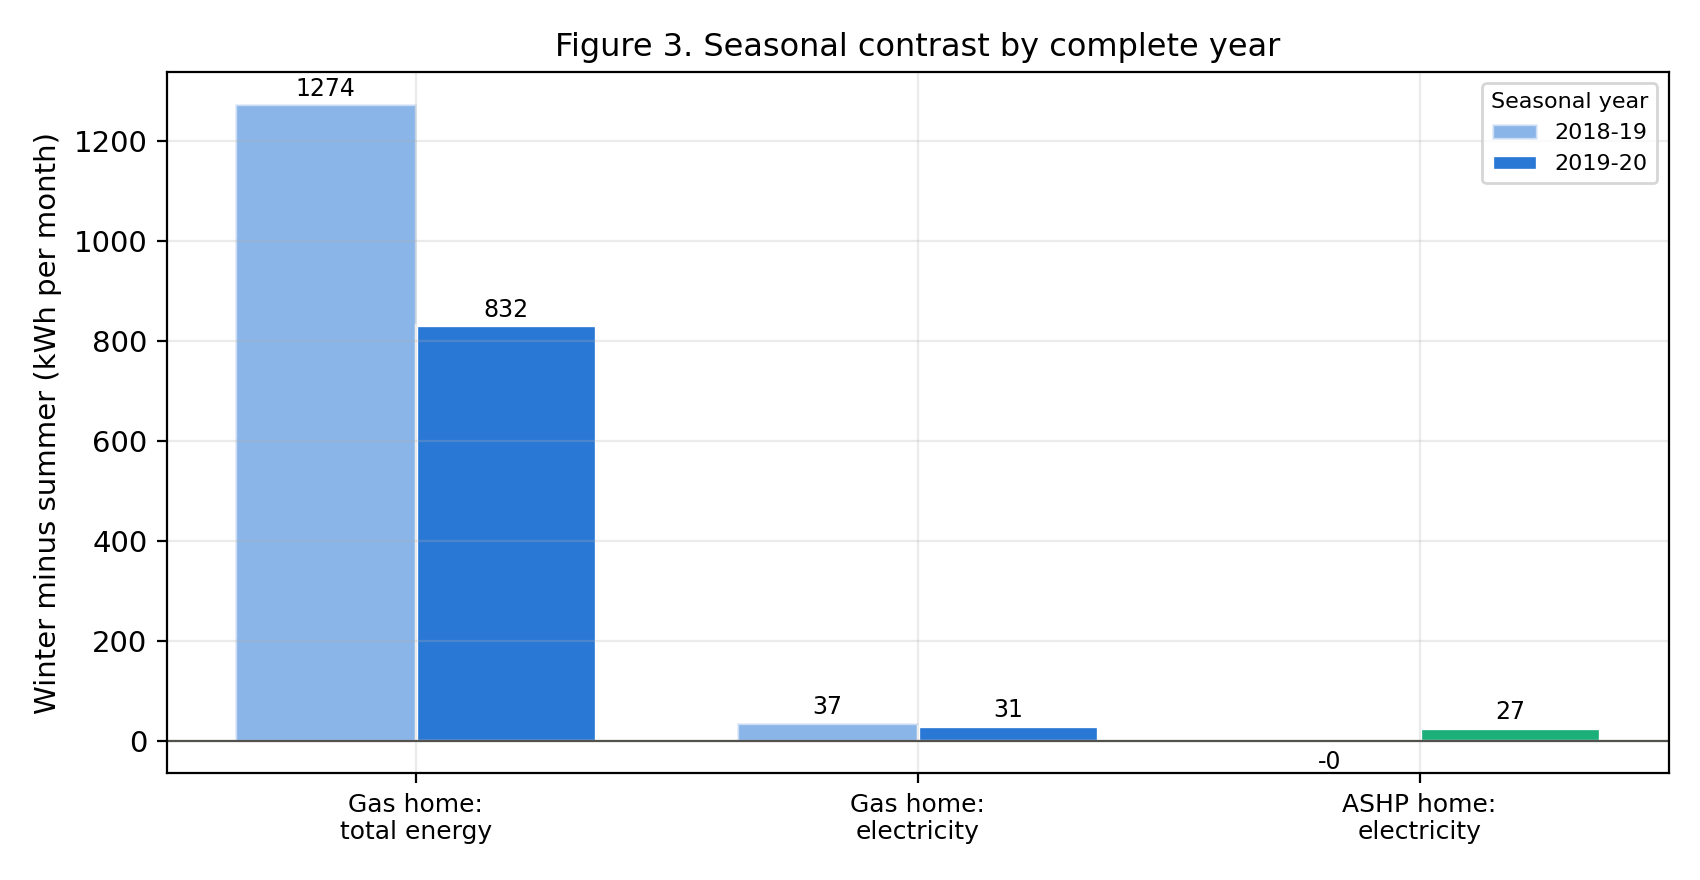

In [22]:
# Figure 2: the three monthly series across the two complete years.
fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.plot(pair.index, pair["gash_total_kwh"], color=C_GAS, marker="o", markersize=4,
        label="Gas home (UPRN 111): gas + electricity")
ax.plot(pair.index, pair["gash_elec_kwh"], color=C_GAS, linewidth=1.2, linestyle="--",
        label="Gas home: electricity only")
ax.plot(pair.index, pair["ashp_elec_kwh"], color=C_ASHP, marker="o", markersize=4,
        label="ASHP home (UPRN 15): recorded electricity")
ax.set_ylabel("Metered energy (kWh per month)"); ax.set_xlabel("Month")
ax.set_title("Figure 2. Two complete seasonal years (Jun 2018 - May 2020)")
ax.legend(loc="upper right")
fig.tight_layout(); fig.savefig(FIG / "fig2_monthly_series.png", dpi=200); plt.close(fig)
show(FIG / "fig2_monthly_series.png")

# Figure 3: per-year winter-minus-summer contrasts.
SERIES = [("gash_total_kwh", "Gas home:\ntotal energy", C_GAS),
          ("gash_elec_kwh",  "Gas home:\nelectricity",  C_GAS),
          ("ashp_elec_kwh",  "ASHP home:\nelectricity", C_ASHP)]
contrasts, ratios = {}, {}
for col, _, _ in SERIES:
    for sy, g in pair.groupby("sy"):
        su, wi = g.index.month.isin(SUMMER), g.index.month.isin(WINTER)
        s_mean, w_mean = g.loc[su, col].mean(), g.loc[wi, col].mean()
        contrasts[f"{col}_{sy}"] = round(float(w_mean - s_mean), 1)
        ratios[f"{col}_{sy}"] = round(float(w_mean / s_mean), 2)

print("winter-minus-summer contrast, kWh/month (winter:summer ratio):")
for k in contrasts:
    print(f"  {k}: {contrasts[k]:>8.1f}  ({ratios[k]:.2f})")

fig, ax = plt.subplots(figsize=(8.5, 4.4))
x, w = np.arange(len(SERIES)), 0.36
for k, (sy, tint) in enumerate([(2018, 0.55), (2019, 1.0)]):
    vals = [contrasts[f"{col}_{sy}"] for col, _, _ in SERIES]
    ax.bar(x + (k - 0.5) * w, vals, w, color=[C_GAS, C_GAS, C_ASHP], alpha=tint,
           edgecolor="white", linewidth=1.2, label=f"{sy}-{str(sy + 1)[2:]}")
    for xi, v in zip(x + (k - 0.5) * w, vals):
        ax.annotate(f"{v:.0f}", (xi, v), xytext=(0, 3 if v >= 0 else -10),
                    textcoords="offset points", ha="center", fontsize=8.5)
ax.axhline(0, color=TEXT_2, linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels([lab for _, lab, _ in SERIES], fontsize=9)
ax.set_ylabel("Winter minus summer (kWh per month)")
ax.set_title("Figure 3. Seasonal contrast by complete year")
ax.legend(title="Seasonal year", fontsize=8, title_fontsize=8)
fig.tight_layout(); fig.savefig(FIG / "fig3_contrasts.png", dpi=200); plt.close(fig)
show(FIG / "fig3_contrasts.png")

## 8. Physics consistency check plus report Figure 4


core heating months 18, of which no uplift at all: 4
implied heat-to-uplift ratio: median 22.1, min 5.5
at SPF 2.9 the recorded uplift covers 9.0% of the matched heat need

first complete year: useful heat 6827 kWh
  January expected uplift at SPF 2.9: 404 kWh
  January observed uplift: 17 kWh


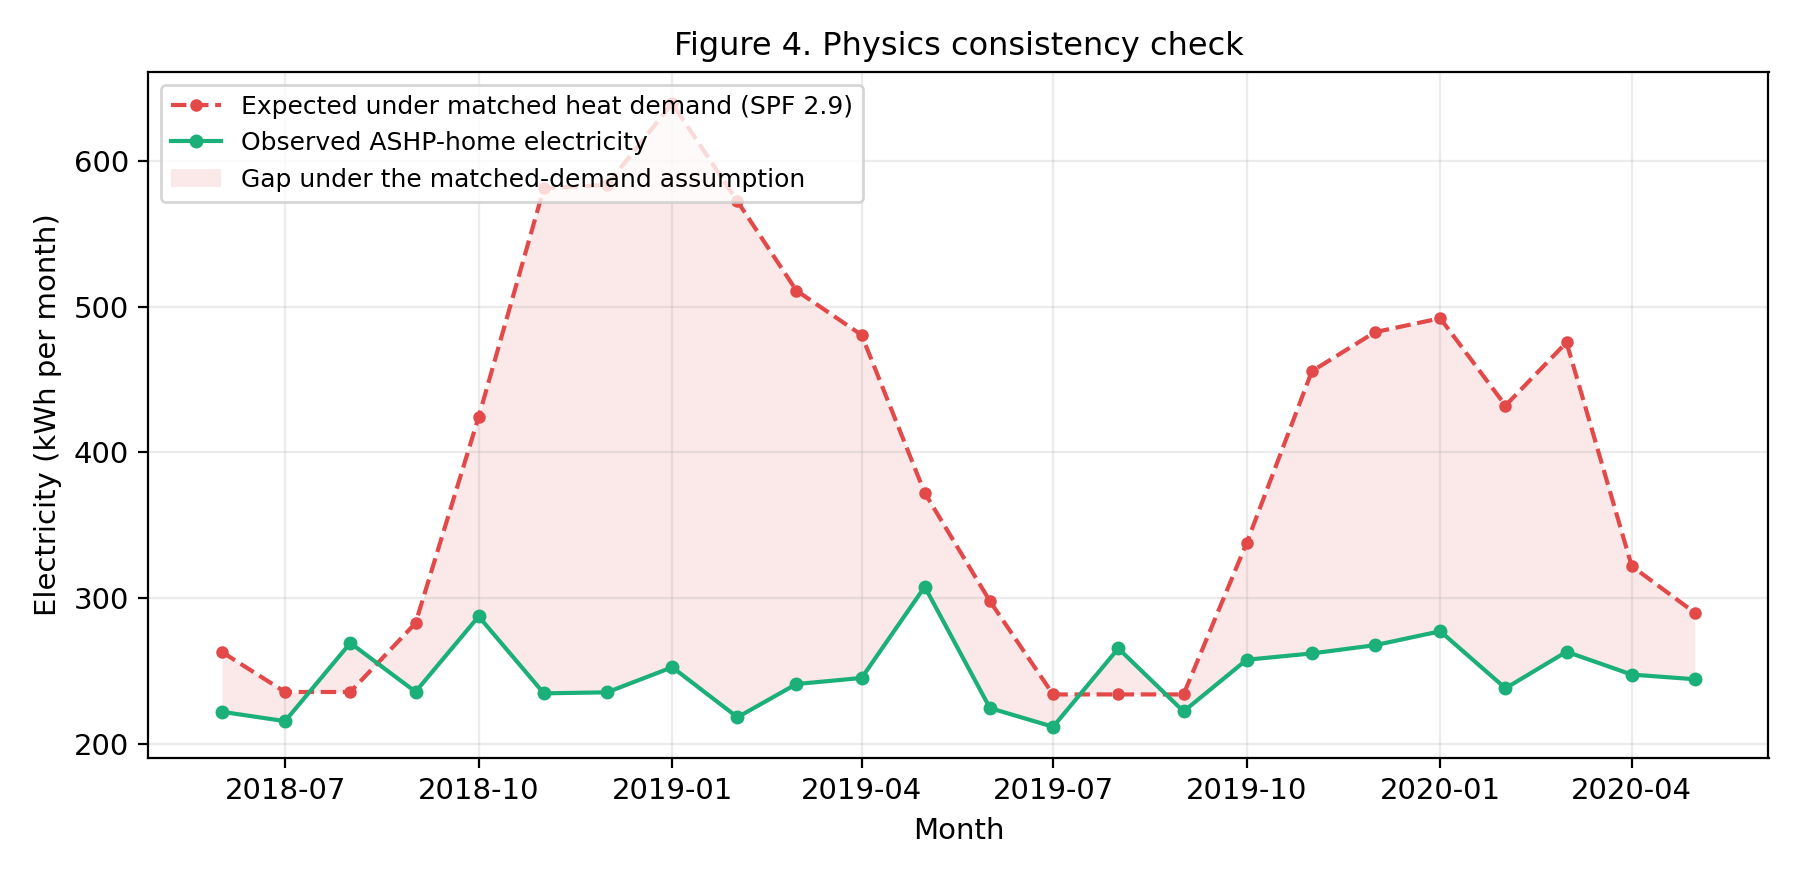

In [23]:
parts = []
for sy, g in pair.groupby("sy"):
    su = g.index.month.isin(SUMMER)
    gas_base  = g.loc[su, "gas_kwh"].mean()          # summer gas = cooking + hot water
    ashp_base = g.loc[su, "ashp_elec_kwh"].mean()    # ASHP home's appliance baseline
    p = pd.DataFrame(index=g.index)
    p["heat"]     = (g["gas_kwh"] - gas_base).clip(lower=0) * BOILER_EFF
    p["uplift"]   = (g["ashp_elec_kwh"] - ashp_base).clip(lower=0)
    p["expected"] = ashp_base + p["heat"] / FIELD_SPF
    p["observed"] = g["ashp_elec_kwh"]
    p["sy"] = sy
    parts.append(p)
phys = pd.concat(parts)

core   = phys["heat"] > 100                                    # real heating months only
nonpos = int((core & (phys["uplift"] <= 0)).sum())
ratio  = (phys.loc[core, "heat"] /
          phys.loc[core, "uplift"].where(phys.loc[core, "uplift"] > 0)).dropna()
coverage = 100 * FIELD_SPF * phys.loc[core, "uplift"].sum() / phys.loc[core, "heat"].sum()

# First complete year, for the January illustration quoted in the report.
y1 = phys[phys["sy"] == 2018]
jan = y1[y1.index.month == 1]
print(f"core heating months {int(core.sum())}, of which no uplift at all: {nonpos}")
print(f"implied heat-to-uplift ratio: median {ratio.median():.1f}, min {ratio.min():.1f}")
print(f"at SPF {FIELD_SPF} the recorded uplift covers {coverage:.1f}% of the matched heat need")
print(f"\nfirst complete year: useful heat {y1['heat'].sum():.0f} kWh")
print(f"  January expected uplift at SPF {FIELD_SPF}: {float(jan['heat'].iloc[0]/FIELD_SPF):.0f} kWh")
print(f"  January observed uplift: {float(jan['uplift'].iloc[0]):.0f} kWh")

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(phys.index, phys["expected"], color=C_EMPH, linestyle="--", marker="o", markersize=3.5,
        label=f"Expected under matched heat demand (SPF {FIELD_SPF})")
ax.plot(phys.index, phys["observed"], color=C_ASHP, marker="o", markersize=4,
        label="Observed ASHP-home electricity")
ax.fill_between(phys.index, phys["observed"], phys["expected"], color=C_EMPH, alpha=0.12,
                linewidth=0, label="Gap under the matched-demand assumption")
ax.set_ylabel("Electricity (kWh per month)"); ax.set_xlabel("Month")
ax.set_title("Figure 4. Physics consistency check")
ax.legend(loc="upper left")
fig.tight_layout(); fig.savefig(FIG / "fig4_physics.png", dpi=200); plt.close(fig)
show(FIG / "fig4_physics.png")

## 9. Corrected economics

In [24]:
yr = pair[pair["sy"] == 2018]                    # first complete June-May year
assert len(yr) == 12
gas_kwh   = float(yr["gas_kwh"].sum())
gash_elec = float(yr["gash_elec_kwh"].sum())
heat        = gas_kwh * BOILER_EFF               # useful heat the boiler delivered
switch_elec = heat / FIELD_SPF                   # ASHP electricity for that same heat

gash_bill   = gas_kwh * P_GAS + SC_GAS + gash_elec * P_ELEC + SC_ELEC
switch_bill = (gash_elec + switch_elec) * P_ELEC + SC_ELEC
central     = gash_bill - switch_bill

print(f"sheet-style gas cost (priced by m3): GBP {float(yr['gas_m3'].sum()) * P_GAS:.0f}"
      f"  vs correct (by kWh): GBP {gas_kwh * P_GAS:.0f}")
print(f"gas home bill GBP {gash_bill:.0f} | within-home switch GBP {switch_bill:.0f} "
      f"(saving GBP {central:.0f})")
print(f"gas standing charge removed by the switch: GBP {SC_GAS:.0f}")

# (a) assumption sweep: boiler efficiency x SPF
assump = np.array([gash_bill - ((gash_elec + gas_kwh * eta / spf) * P_ELEC + SC_ELEC)
                   for eta in (0.75, 0.85, 0.90) for spf in (2.5, 2.9, 3.5)])
print(f"\nassumption sweep (eff 0.75-0.90 x SPF 2.5-3.5): "
      f"GBP {assump.min():.0f} to GBP {assump.max():.0f}")

# (b) price-ratio sweep: gas held at the cap, electricity varied to hit each ratio
print("price-ratio sweep (gas at cap, electricity varied):")
ratio_rows = []
for r in (3.0, FIELD_SPF / BOILER_EFF, P_ELEC / P_GAS, 4.5):
    pe = P_GAS * r
    saving = ((gas_kwh * P_GAS + SC_GAS + gash_elec * pe + SC_ELEC)
              - ((gash_elec + switch_elec) * pe + SC_ELEC))
    ratio_rows.append({"price_ratio": round(r, 2), "saving_gbp": round(saving)})
    print(f"  ratio {r:4.2f}: saving GBP {saving:+.0f}")
ratio_sweep = pd.DataFrame(ratio_rows)

co2_gas    = (gas_kwh * CO2_GAS + gash_elec * CO2_ELEC) / 1000
co2_switch = (gash_elec + switch_elec) * CO2_ELEC / 1000
print(f"\ncarbon: {co2_gas:.2f} -> {co2_switch:.2f} tCO2e/year "
      f"({100 * (1 - co2_switch / co2_gas):.0f}% cut)")

sheet-style gas cost (priced by m3): GBP 67  vs correct (by kWh): GBP 749
gas home bill GBP 1913 | within-home switch GBP 1903 (saving GBP 10)
gas standing charge removed by the switch: GBP 108

assumption sweep (eff 0.75-0.90 x SPF 2.5-3.5): GBP -183 to GBP 238
price-ratio sweep (gas at cap, electricity varied):
  ratio 3.00: saving GBP +198
  ratio 3.41: saving GBP +108
  ratio 3.86: saving GBP +10
  ratio 4.50: saving GBP -131

carbon: 2.47 -> 1.24 tCO2e/year (50% cut)


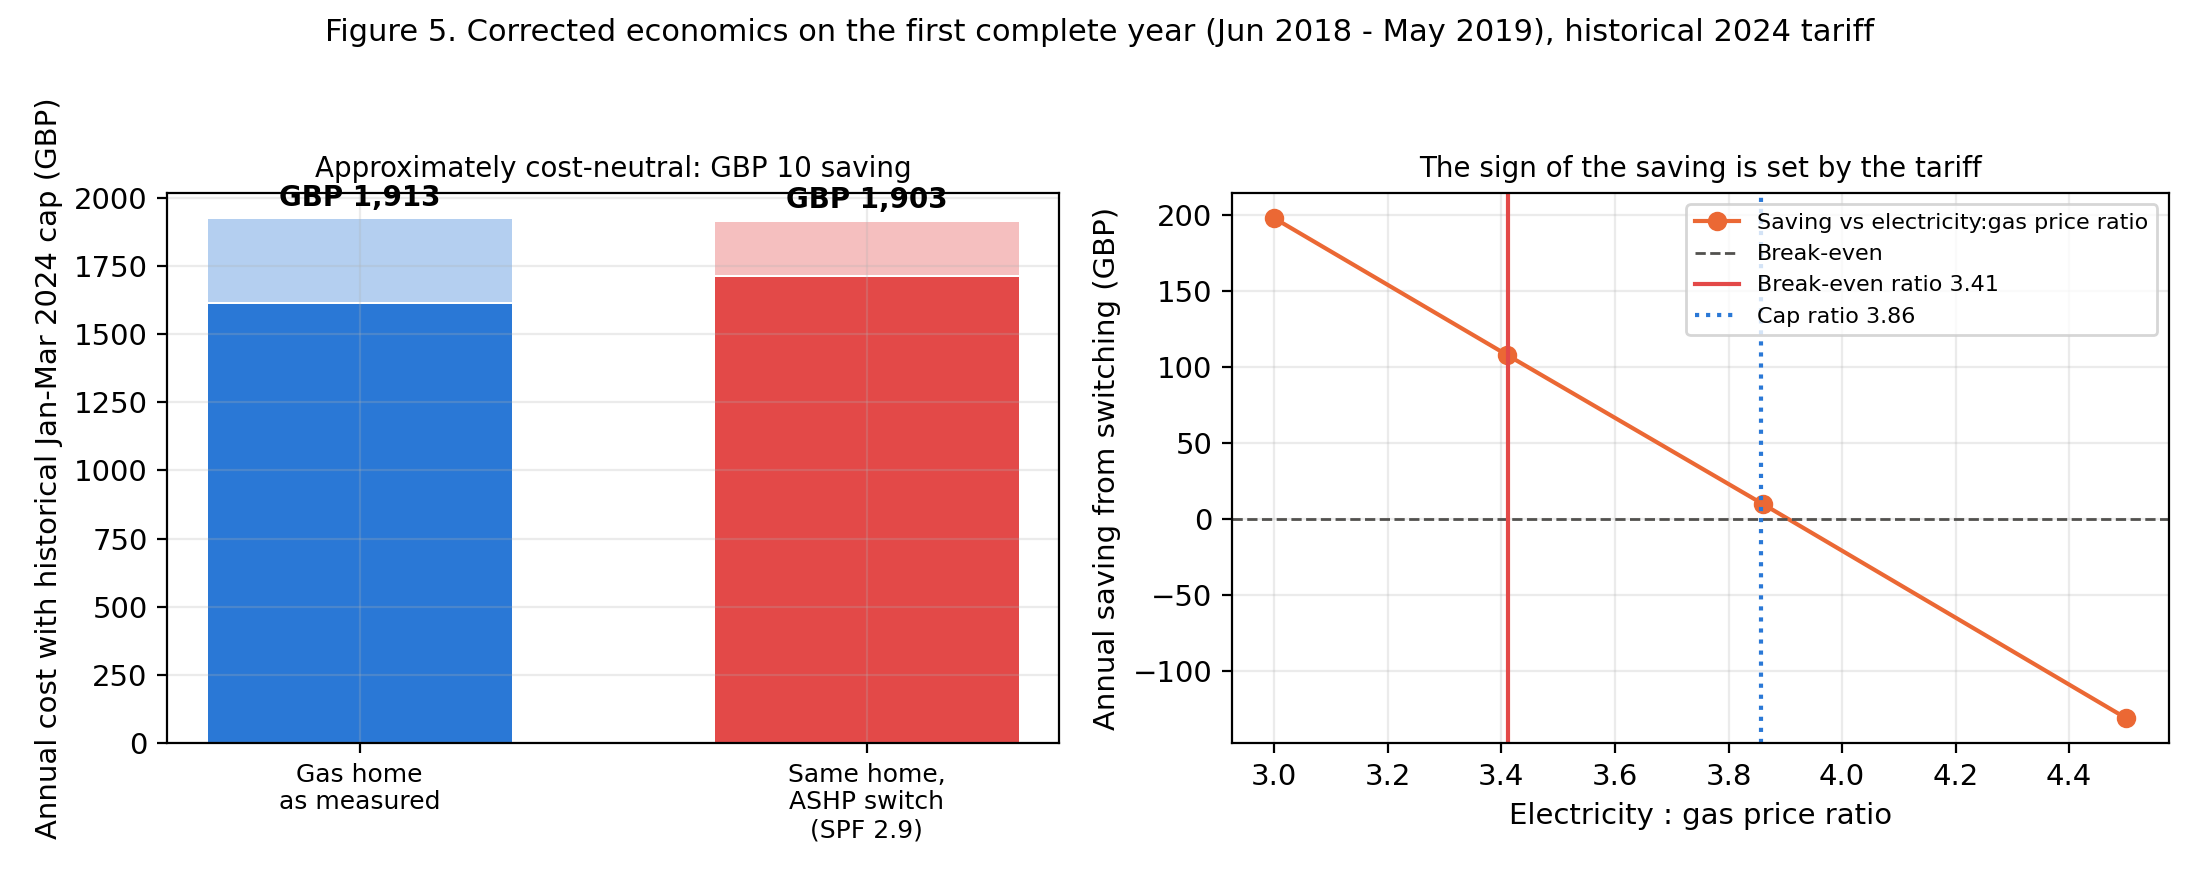

In [25]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 4.4),
                               gridspec_kw={"width_ratios": [1, 1.05]})
labels   = ["Gas home\nas measured", f"Same home,\nASHP switch\n(SPF {FIELD_SPF})"]
fuel     = [gas_kwh * P_GAS + gash_elec * P_ELEC, (gash_elec + switch_elec) * P_ELEC]
standing = [SC_GAS + SC_ELEC, SC_ELEC]
for i, (f_, s_, c) in enumerate(zip(fuel, standing, [C_GAS, C_EMPH])):
    ax0.bar(i, f_, width=0.6, color=c)
    ax0.bar(i, s_, bottom=f_ + 8, width=0.6, color=c, alpha=0.35)
    ax0.annotate(f"GBP {f_ + s_:,.0f}", (i, f_ + s_ + 8), ha="center",
                 xytext=(0, 5), textcoords="offset points", fontsize=10, fontweight="bold")
ax0.set_xticks([0, 1]); ax0.set_xticklabels(labels, fontsize=9)
ax0.set_ylabel("Annual cost with historical Jan-Mar 2024 cap (GBP)")
ax0.set_title(f"Approximately cost-neutral: GBP {central:.0f} saving", fontsize=10)

ax1.plot(ratio_sweep["price_ratio"], ratio_sweep["saving_gbp"], color=C_ALT,
         marker="o", label="Saving vs electricity:gas price ratio")
ax1.axhline(0, color=TEXT_2, linewidth=1, linestyle="--", label="Break-even")
ax1.axvline(FIELD_SPF / BOILER_EFF, color=C_EMPH, linewidth=1.5,
            label=f"Break-even ratio {FIELD_SPF / BOILER_EFF:.2f}")
ax1.axvline(P_ELEC / P_GAS, color=C_GAS, linewidth=1.5, linestyle=":",
            label=f"Cap ratio {P_ELEC / P_GAS:.2f}")
ax1.set_xlabel("Electricity : gas price ratio")
ax1.set_ylabel("Annual saving from switching (GBP)")
ax1.set_title("The sign of the saving is set by the tariff", fontsize=10)
ax1.legend(loc="upper right", fontsize=8)

fig.suptitle("Figure 5. Corrected economics on the first complete year "
             "(Jun 2018 - May 2019), historical 2024 tariff", fontsize=11)
fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.savefig(FIG / "fig6_costs.png", dpi=200); plt.close(fig)
show(FIG / "fig6_costs.png")

## 10. Annual harmonic plus report Figure 5

A four-parameter annual harmonic (intercept, linear trend, one Fourier pair) fitted to the gas home's monthly gas demand.

annual harmonic: 4 parameters, R^2 = 0.91, RMSE = 139.6 kWh/month, MAE = 120.0


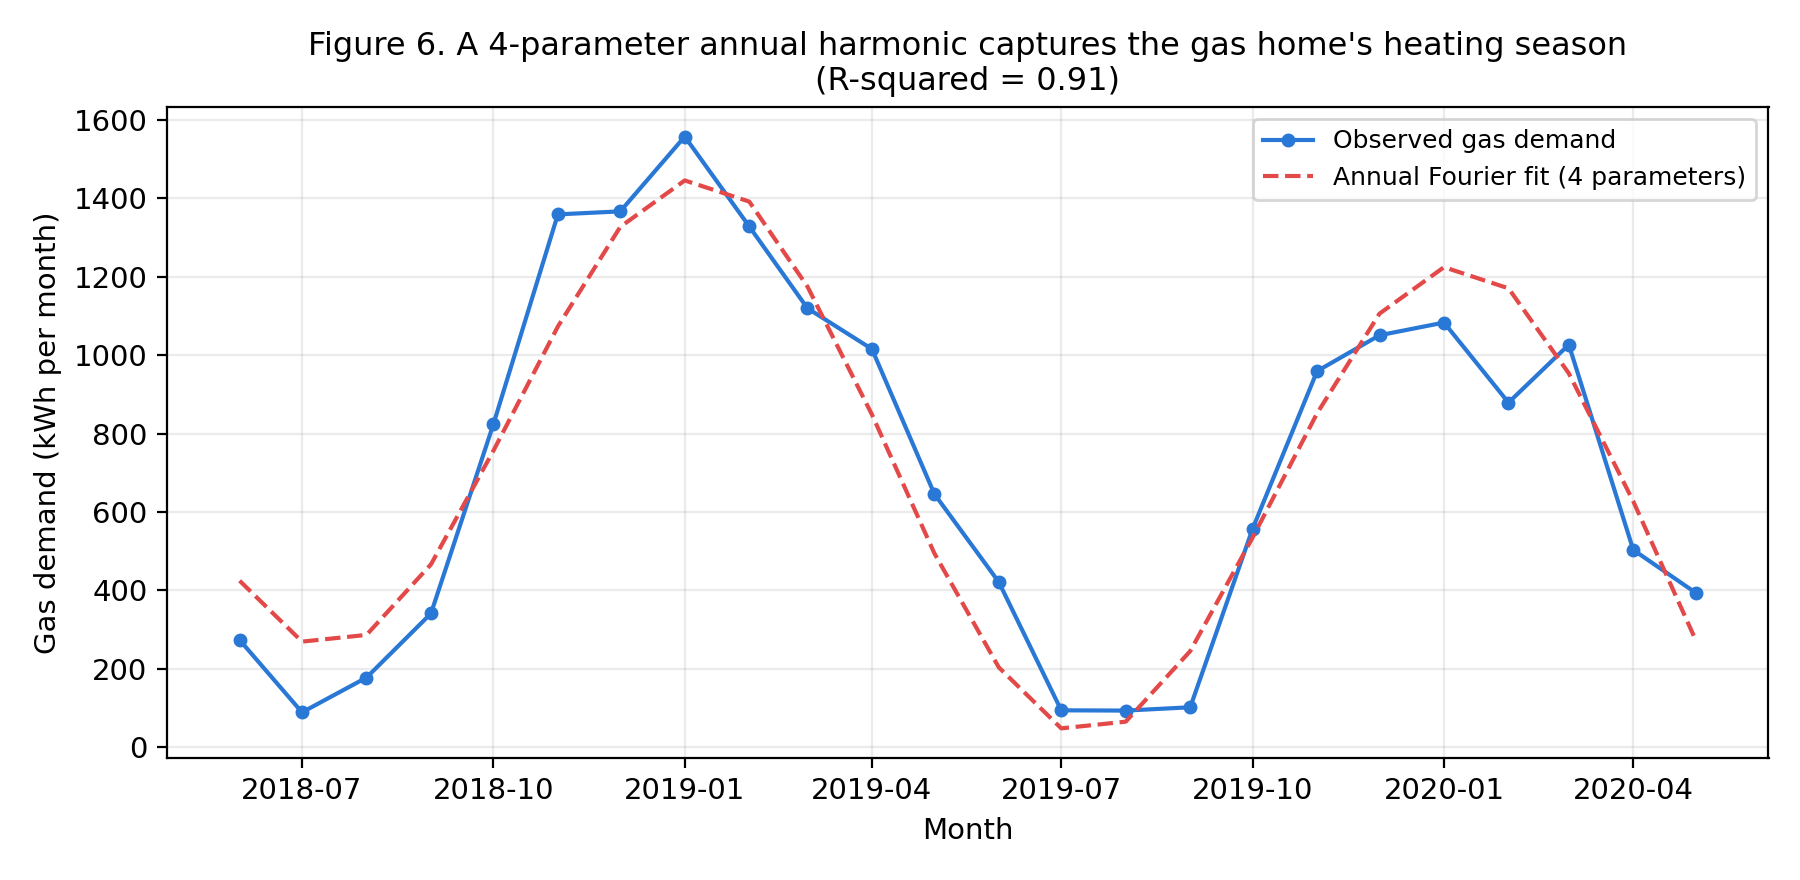

In [26]:
gas_series = pair["gas_kwh"].copy()
t = np.arange(len(gas_series), dtype=float)
X = np.column_stack([np.ones(len(t)), t,
                     np.sin(2 * np.pi * t / 12), np.cos(2 * np.pi * t / 12)])
beta, *_ = np.linalg.lstsq(X, gas_series.to_numpy(), rcond=None)
fit   = pd.Series(X @ beta, index=gas_series.index).clip(lower=0)
resid = gas_series - fit
r2   = 1 - float((resid ** 2).sum()) / float(((gas_series - gas_series.mean()) ** 2).sum())
rmse = float(np.sqrt((resid ** 2).mean()))
mae  = float(resid.abs().mean())
print(f"annual harmonic: {X.shape[1]} parameters, R^2 = {r2:.2f}, "
      f"RMSE = {rmse:.1f} kWh/month, MAE = {mae:.1f}")

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(gas_series.index, gas_series.to_numpy(), color=C_GAS, marker="o", markersize=4,
        label="Observed gas demand")
ax.plot(fit.index, fit.to_numpy(), color=C_EMPH, linestyle="--",
        label="Annual Fourier fit (4 parameters)")
ax.set_ylabel("Gas demand (kWh per month)"); ax.set_xlabel("Month")
ax.set_title("Figure 6. A 4-parameter annual harmonic captures the gas home's heating season\n"
             f"(R-squared = {r2:.2f})")
ax.legend(loc="upper right")
fig.tight_layout(); fig.savefig(FIG / "fig5_harmonic.png", dpi=200); plt.close(fig)
show(FIG / "fig5_harmonic.png")